In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving superstoredataset.csv to superstoredataset.csv


In [ ]:
df = pd.read_csv("superstoredataset.csv", encoding='latin1')

df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [ ]:
df.isnull().sum()


,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.drop_duplicates(inplace=True)

In [ ]:
df['Order Date'] = pd.to_datetime(
    df['Order Date'],
    errors='coerce'
)

df['Ship Date'] = pd.to_datetime(
    df['Ship Date'],
    errors='coerce'
)

In [ ]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

In [ ]:
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month
df['Day'] = df['Order Date'].dt.day
df['Quarter'] = df['Order Date'].dt.quarter
df['Weekday'] = df['Order Date'].dt.dayofweek

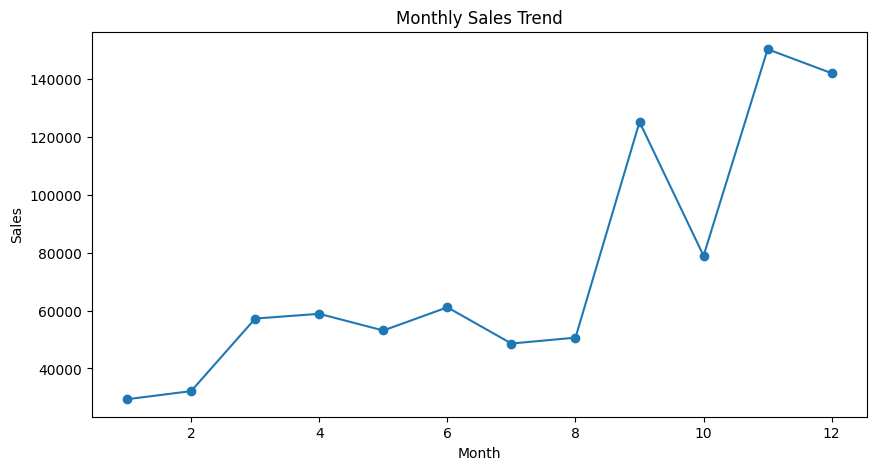

In [ ]:
monthly_sales = df.groupby('Month')['Sales'].sum()

plt.figure(figsize=(10,5))
monthly_sales.plot(marker='o')
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Sales')
plt.show()

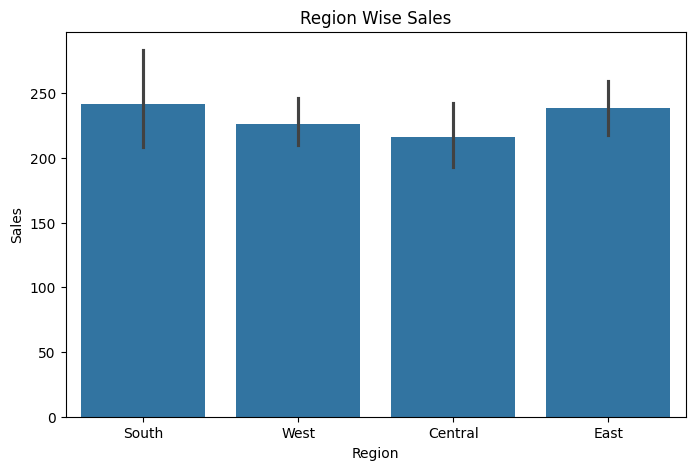

In [ ]:
plt.figure(figsize=(8,5))
sns.barplot(x='Region',y='Sales',data=df)
plt.title('Region Wise Sales')
plt.show()

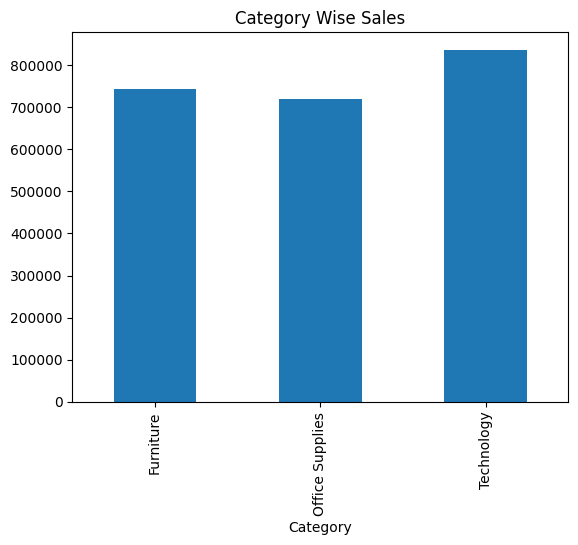

In [ ]:
category_sales = df.groupby('Category')['Sales'].sum()

category_sales.plot(kind='bar')
plt.title('Category Wise Sales')
plt.show()

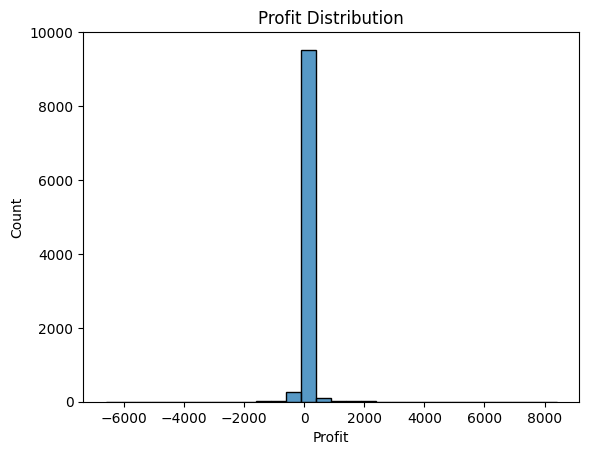

In [ ]:
sns.histplot(df['Profit'],bins=30)
plt.title("Profit Distribution")
plt.show()

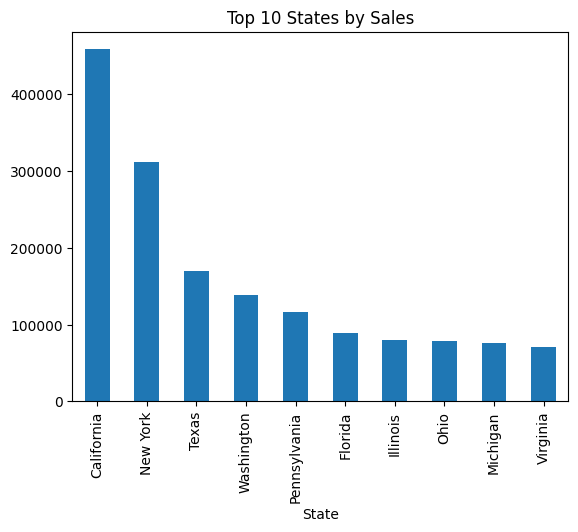

In [ ]:
top_states = df.groupby('State')['Sales'].sum().sort_values(ascending=False).head(10)

top_states.plot(kind='bar')
plt.title('Top 10 States by Sales')
plt.show()

In [ ]:
daily_sales = df.groupby('Order Date')['Sales'].sum().reset_index()

In [ ]:
daily_sales['Year'] = daily_sales['Order Date'].dt.year
daily_sales['Month'] = daily_sales['Order Date'].dt.month
daily_sales['Day'] = daily_sales['Order Date'].dt.day

In [ ]:
X = daily_sales[['Year','Month','Day']]
y = daily_sales['Sales']

In [ ]:
X_train,X_test,y_train,y_test = train_test_split(
    X,y,
    test_size=0.2,
    random_state=42
)


In [ ]:
model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

model.fit(X_train,y_train)

RandomForestRegressor(n_estimators=200, random_state=42)

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
mae = mean_absolute_error(y_test,y_pred)
rmse = np.sqrt(mean_squared_error(y_test,y_pred))
r2 = r2_score(y_test,y_pred)

print("MAE :",mae)
print("RMSE :",rmse)
print("R2 :",r2)

MAE : 1494.375856546392
RMSE : 1965.6525338027925
R2 : -0.22727709916351602


In [ ]:
future = pd.DataFrame({
    'Year':[2026,2026,2026,2026,2026,2026],
    'Month':[1,2,3,4,5,6],
    'Day':[1,1,1,1,1,1]
})

future_sales = model.predict(future)

future['Forecast Sales'] = future_sales

print(future)

   Year  Month  Day  Forecast Sales
0  2026      1    1     1787.961945
1  2026      2    1     1733.597012
2  2026      3    1     4566.147225
3  2026      4    1     4722.997695
4  2026      5    1     3806.590285
5  2026      6    1     3153.305320


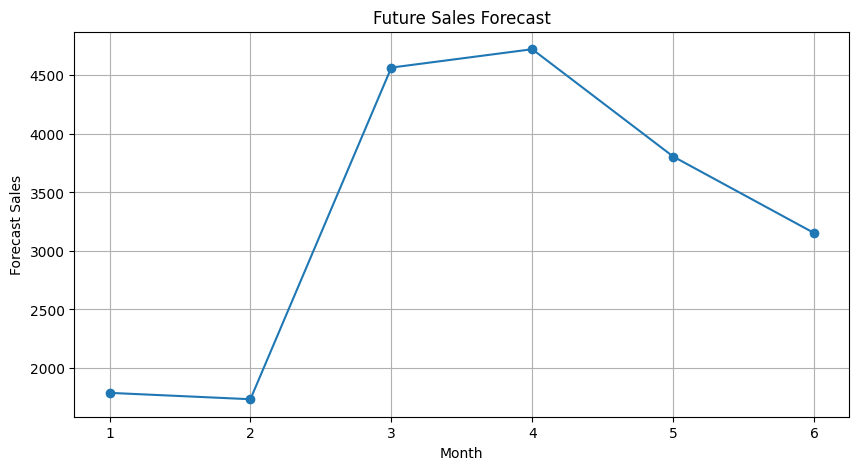

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(
    future['Month'],
    future['Forecast Sales'],
    marker='o'
)

plt.title('Future Sales Forecast')
plt.xlabel('Month')
plt.ylabel('Forecast Sales')
plt.grid(True)

plt.show()